# Домашнее задание №3

In [5]:
# Скачивание датасета с сайта kagglehub
import kagglehub

# Download latest version
path = kagglehub.dataset_download("khoongweihao/aaplcsv")

print("Path to dataset files:", path)

100%|██████████| 4.90k/4.90k [00:00<00:00, 2.01MB/s]

Extracting files...
Path to dataset files: /Users/doriangray/.cache/kagglehub/datasets/khoongweihao/aaplcsv/versions/1


## Задание №1
На основании датасета для каждого покупателя получите:
- предпочитаемый метод оплаты;
- общие траты;
- количество денег, потраченных на дополнительные услуги и аксессуары.

In [15]:
import pandas as pd
df = pd.read_csv('Electronic_sales_Sep2023-Sep2024.csv')
df.head()

,Customer ID,Age,Gender,Loyalty Member,Product Type,SKU,Rating,Order Status,Payment Method,Total Price,Unit Price,Quantity,Purchase Date,Shipping Type,Add-ons Purchased,Add-on Total
0,1000,53,Male,No,Smartphone,SKU1004,2,Cancelled,Credit Card,5538.33,791.19,7,2024-03-20,Standard,"Accessory,Accessory,Accessory",40.21
1,1000,53,Male,No,Tablet,SKU1002,3,Completed,Paypal,741.09,247.03,3,2024-04-20,Overnight,Impulse Item,26.09
2,1002,41,Male,No,Laptop,SKU1005,3,Completed,Credit Card,1855.84,463.96,4,2023-10-17,Express,NaN,0.00
3,1002,41,Male,Yes,Smartphone,SKU1004,2,Completed,Cash,3164.76,791.19,4,2024-08-09,Overnight,"Impulse Item,Impulse Item",60.16
4,1003,75,Male,Yes,Smartphone,SKU1001,5,Completed,Cash,41.50,20.75,2,2024-05-21,Express,Accessory,35.56


In [19]:
completed_df = df[df['Order Status'] == 'Completed']
grouped_df = df.groupby('Customer ID')

preferred_method = grouped_df['Payment Method'].apply(lambda method: method.mode()[0] if not method.mode().empty else None)

total_spend = grouped_df['Total Price'].sum()

addon_spend = grouped_df['Add-on Total'].sum()

result_task1 = pd.DataFrame({
    'Preferred method' : preferred_method,
    'Total spend' : total_spend,
    'Add-on spend' : addon_spend
})

result_task1

,Preferred method,Total spend,Add-on spend
Customer ID,,,
1000,Credit Card,6279.42,66.30
1002,Cash,5020.60,60.16
1003,Cash,41.50,35.56
1004,Credit Card,83.00,65.78
1005,Debit Card,11779.11,75.33
...,...,...,...
19994,Bank Transfer,5504.87,93.17
19995,Credit Card,5394.56,0.00
19996,Bank Transfer,27296.78,432.12


## Задание 2
1. На основании датасета получите доход:
- по каждому методу доставки,
- по каждому типу продукта,
- по дополнительным услугам за каждый месяц,
- по дополнительным услугам за каждый квартал.
2. Отобразите полученные данные на графике.


/var/folders/2c/7m29zgt920lfdm8l10xcrkg40000gn/T/ipykernel_818/3924390550.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_df['month'] = pd.to_datetime(completed_df['Purchase Date']).dt.month
/var/folders/2c/7m29zgt920lfdm8l10xcrkg40000gn/T/ipykernel_818/3924390550.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  completed_df['quarter'] = pd.to_datetime(completed_df['Purchase Date']).dt.quarter


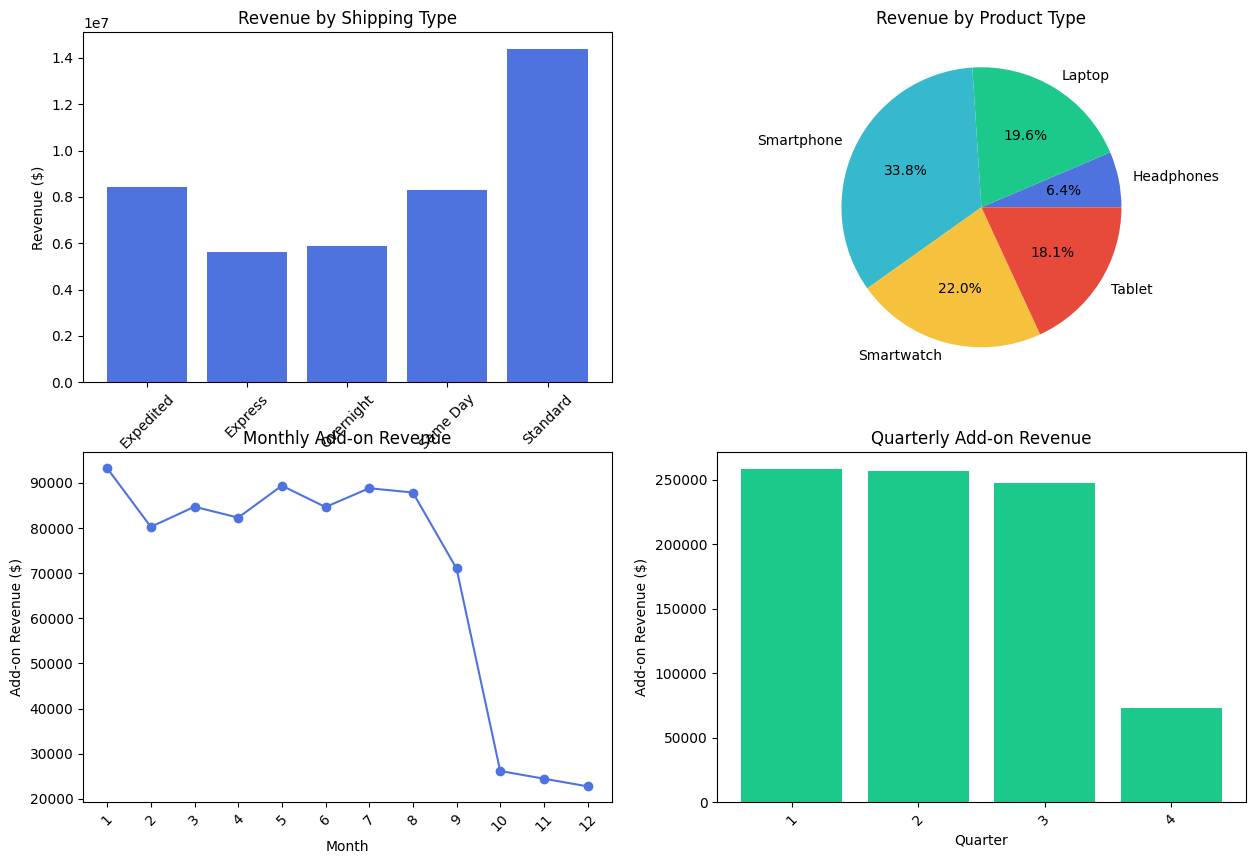

In [40]:
import numpy as np
import matplotlib.pyplot as plt

total_revenue_shipping_type = completed_df.groupby('Shipping Type')['Total Price'].sum()
shipping_labels = total_revenue_shipping_type.index.to_numpy()
shipping_values = total_revenue_shipping_type.values

total_revenue_product_type = completed_df.groupby('Product Type')['Total Price'].sum()
product_labels = total_revenue_product_type.index.to_numpy()
product_values = total_revenue_product_type.values

completed_df['month'] = pd.to_datetime(completed_df['Purchase Date']).dt.month
monthly_revenue_addons = completed_df.groupby('month')['Add-on Total'].sum()
month_labels = monthly_revenue_addons.index.astype(str).to_numpy()
month_values = monthly_revenue_addons.values

completed_df['quarter'] = pd.to_datetime(completed_df['Purchase Date']).dt.quarter
quarter_revenue_addons = completed_df.groupby('quarter')['Add-on Total'].sum()
quarter_labels = quarter_revenue_addons.index.astype(str).to_numpy()
quarter_values = quarter_revenue_addons.values

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

axes[0, 0].bar(shipping_labels, shipping_values, color='#4e73df')
axes[0, 0].set_title('Revenue by Shipping Type')
axes[0, 0].set_xlabel('Shipping Type')
axes[0, 0].set_ylabel('Revenue ($)')
axes[0, 0].tick_params(axis='x', rotation=45)

axes[0, 1].pie(product_values, labels=product_labels, autopct='%1.1f%%', colors=['#4e73df', '#1cc88a', '#36b9cc', '#f6c23e', '#e74a3b'])
axes[0, 1].set_title('Revenue by Product Type')

axes[1, 0].plot(month_labels, month_values, marker='o', color='#4e73df')
axes[1, 0].set_title('Monthly Add-on Revenue')
axes[1, 0].set_xlabel('Month')
axes[1, 0].set_ylabel('Add-on Revenue ($)')
axes[1, 0].tick_params(axis='x', rotation=45)

axes[1, 1].bar(quarter_labels, quarter_values, color='#1cc88a')
axes[1, 1].set_title('Quarterly Add-on Revenue')
axes[1, 1].set_xlabel('Quarter')
axes[1, 1].set_ylabel('Add-on Revenue ($)')
axes[1, 1].tick_params(axis='x', rotation=45)

plt.show()